In [ ]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'venv', r'C:\Users\bacus\tf_env'], capture_output=False)

pip = r'C:\Users\bacus\tf_env\Scripts\pip.exe'
subprocess.run([pip, 'install', 'tensorflow==2.17.0'], capture_output=False)
subprocess.run([pip, 'install', 'opencv-python', 'albumentations',
                'scikit-learn', 'matplotlib', 'seaborn', 
                'ipykernel'], capture_output=False)

print("Done!")

Done!


In [2]:
import subprocess
python = r'C:\Users\bacus\tf_env\Scripts\python.exe'
subprocess.run([python, '-m', 'ipykernel', 'install', 
                '--user', '--name=tf_env', '--display-name=Python (tf_env)'], 
               capture_output=False)
print("Kernel registered!")

Kernel registered!


In [3]:
import tensorflow as tf
print("TF version:", tf.__version__)

TF version: 2.18.0


In [4]:
from pathlib import Path
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
import albumentations as A
from albumentations.core.composition import Compose
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPUs:", gpus)

TF version: 2.18.0
Keras version: 3.14.0
GPUs: []


In [5]:
DATASET_ROOT_PATH = r'C:\Users\bacus\Documents\Cariex Dataset'
IMG_SIZE   = 256
BATCH_SIZE = 8
EPOCHS     = 30
MODEL_NAME = 'cariex_classifier'

CARIES_CLASSES = ['healthy', 'incipient_caries', 'moderate_caries', 'deep_caries']
JAWS        = ['Lower', 'Upper']
NUM_CLASSES = len(CARIES_CLASSES)

print(f"Classes: {CARIES_CLASSES}")
print(f"Num classes: {NUM_CLASSES}")

Classes: ['healthy', 'incipient_caries', 'moderate_caries', 'deep_caries']
Num classes: 4


In [6]:
train_transforms = Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.Rotate(limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])

val_transforms = Compose([])

In [7]:
def scan_dataset(root):
    root = Path(root)
    paths, labels = [], []

    for jaw in JAWS:
        for caries_idx, caries_name in enumerate(CARIES_CLASSES):
            folder = root / jaw / caries_name
            if not folder.exists():
                print(f"Warning: not found — {folder}")
                continue
            for img_path in folder.iterdir():
                if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                    paths.append(str(img_path))
                    labels.append(caries_idx)

    print(f"\nTotal images: {len(paths)}")
    for i, name in enumerate(CARIES_CLASSES):
        print(f"  Class {i} ({name}): {labels.count(i)} images")
    return paths, labels

all_paths, all_labels = scan_dataset(DATASET_ROOT_PATH)


Total images: 741
  Class 0 (healthy): 431 images
  Class 1 (incipient_caries): 59 images
  Class 2 (moderate_caries): 57 images
  Class 3 (deep_caries): 194 images


In [8]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)
print(f"Train: {len(train_paths)}  |  Val: {len(val_paths)}")

Train: 592  |  Val: 149


In [9]:
def load_image(img_path, img_size, transforms=None):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Failed to load: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    if transforms:
        img = transforms(image=img)['image']
    img = img.astype(np.float32) / 255.0
    return img

def create_dataset(paths, labels, img_size, batch_size, transforms=None):
    images, valid_labels = [], []

    for p, l in zip(paths, labels):
        try:
            img = load_image(p, img_size, transforms)
            images.append(img)
            valid_labels.append(l)
        except Exception as e:
            print(f"Skipping {p}: {e}")

    images    = np.array(images, dtype=np.float32)
    labels_oh = keras.utils.to_categorical(valid_labels, num_classes=NUM_CLASSES)

    print(f"Loaded {len(images)} images | shape: {images.shape}")

    ds = tf.data.Dataset.from_tensor_slices((images, labels_oh))
    ds = ds.shuffle(min(1000, len(images))).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, len(images)

print("Loading train...")
train_dataset, train_count = create_dataset(train_paths, train_labels, IMG_SIZE, BATCH_SIZE, train_transforms)
print("Loading val...")
val_dataset, val_count     = create_dataset(val_paths, val_labels, IMG_SIZE, BATCH_SIZE, val_transforms)
print(f"\nTrain: {train_count}  |  Val: {val_count}")

Loading train...
Loaded 592 images | shape: (592, 256, 256, 3)
Loading val...
Loaded 149 images | shape: (149, 256, 256, 3)

Train: 592  |  Val: 149


In [10]:
def conv_block(inputs, filters):
    x = keras.layers.Conv2D(filters, 3, padding='same')(inputs)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    x = keras.layers.Conv2D(filters, 3, padding='same')(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Activation('relu')(x)
    return x

def encoder_block(inputs, filters):
    x = conv_block(inputs, filters)
    p = keras.layers.MaxPooling2D((2, 2))(x)
    return x, p

def build_classifier(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    b1 = conv_block(p4, 1024)
    b1 = Dropout(0.3)(b1)

    x = keras.layers.GlobalAveragePooling2D()(b1)
    x = keras.layers.Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    x = keras.layers.Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CariexClassifier')

model = build_classifier()
model.summary()

Model: "CariexClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 256)    │             

 Total params: 19,154,884 (73.07 MB)

 Trainable params: 19,146,948 (73.04 MB)

 Non-trainable params: 7,936 (31.00 KB)

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

In [12]:
output_dir = Path(f'trained_models/{MODEL_NAME}')
output_dir.mkdir(parents=True, exist_ok=True)

callbacks = [
    ModelCheckpoint(str(output_dir / 'best_model.keras'),
                    monitor='val_accuracy', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10,
                  mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                      patience=5, mode='max', min_lr=1e-7, verbose=1),
    CSVLogger(str(output_dir / 'training_log.csv')),
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4260 - auc: 0.7109 - loss: 1.3039
Epoch 1: val_accuracy improved from None to 0.58389, saving model to trained_models\cariex_classifier\best_model.keras

Epoch 1: finished saving model to trained_models\cariex_classifier\best_model.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.4831 - auc: 0.7388 - loss: 1.2555 - val_accuracy: 0.5839 - val_auc: 0.7827 - val_loss: 1.1135 - learning_rate: 1.0000e-04
Epoch 2/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5532 - auc: 0.7868 - loss: 1.0975
Epoch 2: val_accuracy did not improve from 0.58389
74/74 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.5642 - auc: 0.7795 - loss: 1.1195 - val_accuracy: 0.5839 - val_auc: 0.8167 - val_loss: 1.2192 - learning_rate: 1.0000e-04
Epoch 3/30
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5567 - auc: 0.7736 - loss: 1.1264
Epoch 3: val_accuracy did not improve from 0.58389
74/74 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy:

In [13]:
best_model = keras.models.load_model(str(output_dir / 'best_model.keras'))
results = best_model.evaluate(val_dataset, verbose=1)
print(f"Loss: {results[0]:.4f} | Accuracy: {results[1]:.4f} | AUC: {results[2]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 671ms/step - accuracy: 0.6711 - auc: 0.8363 - loss: 0.9682
Loss: 0.9682 | Accuracy: 0.6711 | AUC: 0.8363


In [14]:
best_model = keras.models.load_model(str(output_dir / 'best_model.keras'))
results = best_model.evaluate(val_dataset, verbose=1)
print(f"Loss: {results[0]:.4f} | Accuracy: {results[1]:.4f} | AUC: {results[2]:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 647ms/step - accuracy: 0.6711 - auc: 0.8363 - loss: 0.9682
Loss: 0.9682 | Accuracy: 0.6711 | AUC: 0.8363


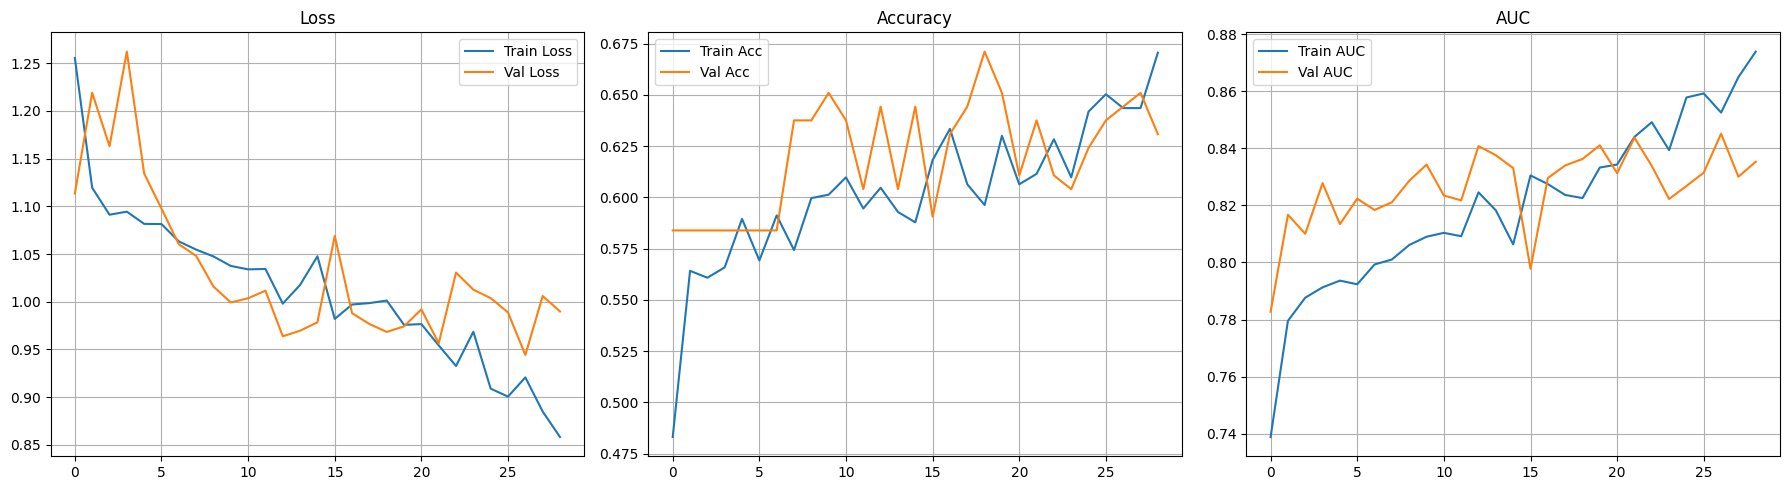

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC'); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

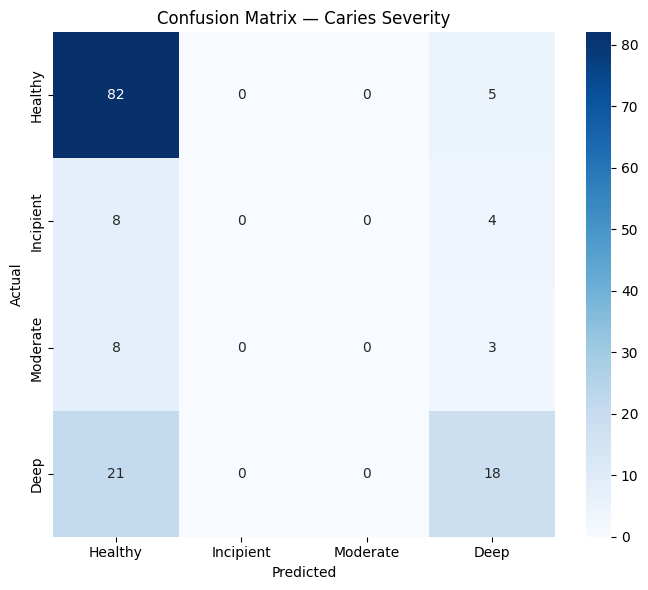

              precision    recall  f1-score   support

     Healthy       0.69      0.94      0.80        87
   Incipient       0.00      0.00      0.00        12
    Moderate       0.00      0.00      0.00        11
        Deep       0.60      0.46      0.52        39

    accuracy                           0.67       149
   macro avg       0.32      0.35      0.33       149
weighted avg       0.56      0.67      0.60       149



c:\Users\bacus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bacus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\bacus\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true, y_pred = [], []
for imgs, lbls in val_dataset:
    preds = best_model.predict(imgs, verbose=0)
    y_true.extend(np.argmax(lbls.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Incipient', 'Moderate', 'Deep'],
            yticklabels=['Healthy', 'Incipient', 'Moderate', 'Deep'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Caries Severity')
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred,
      target_names=['Healthy', 'Incipient', 'Moderate', 'Deep']))